Netflix Data Analysis

Questions We Have To Answer By Analysing Data

Q1- What is the most frequent genre of movies released on Netflix

Q2- What genres has highest votes?

Q3- What movie got the highest popularity? what's its genre?

Q4- What movie got the lowest popularity? what's its genre?

Q5- Which year has the most filmmed movies?

In [1]:
## IMPORTING ALL THE REQUIRED LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## READING THE DATASET

df = pd.read_csv(
    r"D:\IPCS Workspace\MyProject\mymoviedb.csv", 
    engine='python'
)

In [3]:
## CHECKING THE DATASET

df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
## CHECKING INFORMATION ABOUT THE DATASET

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [5]:
## COLUMNS IN THE DATASET

df.columns

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url'],
      dtype='object')

In [6]:
## Types of genres data in dataset.

df["Genre"]

0       Action, Adventure, Science Fiction
1                 Crime, Mystery, Thriller
2                                 Thriller
3       Animation, Comedy, Family, Fantasy
4         Action, Adventure, Thriller, War
                       ...                
9832                          Drama, Crime
9833                                Horror
9834             Mystery, Thriller, Horror
9835                 Music, Drama, History
9836           War, Drama, Science Fiction
Name: Genre, Length: 9837, dtype: object

In [7]:
# In preprocessing we will remove the null values and also we will remove the duplicate values from the dataset. 
# We will also remove the columns which are not needed for our analysis.
# We will also change the data types of the columns which is not in the correct format.
# We will manage the white space in the dataset.

**Data preprocessing**

In [8]:
## CHECKING FOR NULL VALUES

print(df.isnull().sum())

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64


In [9]:
## Removing the null values from the dataset.

df.dropna(inplace=True)

In [10]:
## Null value is removed.

df.isnull().sum()

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

In [11]:
## CHECKING FOR DUPLICATE VALUES

print(df.duplicated().sum())

## no duplicate values are present in the dataset.

0


In [12]:
## Changing the data type of Release_date column to datetime format.

df["Release_Date"] = pd.to_datetime(df["Release_Date"])
print(df["Release_Date"].dtypes)

datetime64[ns]


In [13]:
## Changing the data type of Release_date column to year format.

df["Release_Date"] = df["Release_Date"].dt.year
df["Release_Date"].dtype

dtype('int32')

In [14]:
## changing the data type of 'Vote_Count' and 'Vote_Average' columns accordingly.
df["Vote_Count"] = df["Vote_Count"].astype(int)
df["Vote_Average"] = df["Vote_Average"].astype(float)

In [15]:
## Removing columns which are not needed for our analysis. Like 'Overview', 'Original_language' and 'Poster_URL'.

df.drop(['Overview', 'Original_Language', 'Poster_Url'], axis=1, inplace=True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [16]:
## CHECKING THE DATASET

df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9826 entries, 0 to 9836
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Release_Date  9826 non-null   int32  
 1   Title         9826 non-null   object 
 2   Popularity    9826 non-null   float64
 3   Vote_Count    9826 non-null   int64  
 4   Vote_Average  9826 non-null   float64
 5   Genre         9826 non-null   object 
dtypes: float64(2), int32(1), int64(1), object(2)
memory usage: 499.0+ KB


In [18]:
df.describe()

,Release_Date,Popularity,Vote_Count,Vote_Average
count,9826.000000,9826.000000,9826.000000,9826.000000
mean,2006.202931,40.323951,1392.943721,6.439467
std,15.686202,108.879332,2611.303856,1.129797
min,1902.000000,13.354000,0.000000,0.000000
25%,2000.000000,16.128250,146.000000,5.900000
50%,2011.000000,21.195000,444.000000,6.500000
75%,2017.000000,35.179250,1376.000000,7.100000
max,2024.000000,5083.954000,31077.000000,10.000000


**Categorizing 'Vote Average' Column**

We would cut the 'Vote Average' values and make 4 categories: 'Popular' 'Average' 'Below Average' 'Not Popular' to describe it.

In [19]:
def categorize_col(df, col, labels):

    edges = [df[col].describe()['min'],
             df[col].describe()['25%'],
             df[col].describe()['50%'],
             df[col].describe()['75%'],
             df[col].describe()['max']]
    
    df[col] = pd.cut(df[col], edges, labels=labels, duplicates='drop')
    return df

In [20]:
labels = ['not_popular', 'below_average', 'average', 'popular']

categorize_col(df, 'Vote_Average', labels)

df['Vote_Average'].unique()

['popular', 'below_average', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_average' < 'average' < 'popular']

In [21]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_average,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [22]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular      2467
popular          2450
average          2411
below_average    2398
Name: count, dtype: int64

We would split genres into a list and then explode our dataframe to have only one genre per row for each movie.

In [23]:
df['Genre'] = df['Genre'].str.split(', ')

df = df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [24]:
## Casting column into category.

df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25792 entries, 0 to 25791
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25792 non-null  int32   
 1   Title         25792 non-null  object  
 2   Popularity    25792 non-null  float64 
 3   Vote_Count    25792 non-null  int64   
 4   Vote_Average  25551 non-null  category
 5   Genre         25792 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 756.6+ KB


In [26]:
df['Vote_Average'].mode()

0    average
Name: Vote_Average, dtype: category
Categories (4, object): ['not_popular' < 'below_average' < 'average' < 'popular']

In [ ]:
df.fillna({"Vote_Average": "average"}, inplace=True)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25792 entries, 0 to 25791
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25792 non-null  int32   
 1   Title         25792 non-null  object  
 2   Popularity    25792 non-null  float64 
 3   Vote_Count    25792 non-null  int64   
 4   Vote_Average  25792 non-null  category
 5   Genre         25792 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 756.6+ KB


In [29]:
df.nunique()

Release_Date     102
Title           9512
Popularity      8159
Vote_Count      3266
Vote_Average       4
Genre             19
dtype: int64

In [30]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


**Data Visualisation and interpritation**

In [31]:
sns.set_style('whitegrid')

What is the most frequent genre of movies released on Netflix?

In [32]:
df['Genre'].describe()

count     25792
unique       19
top       Drama
freq       3744
Name: Genre, dtype: object

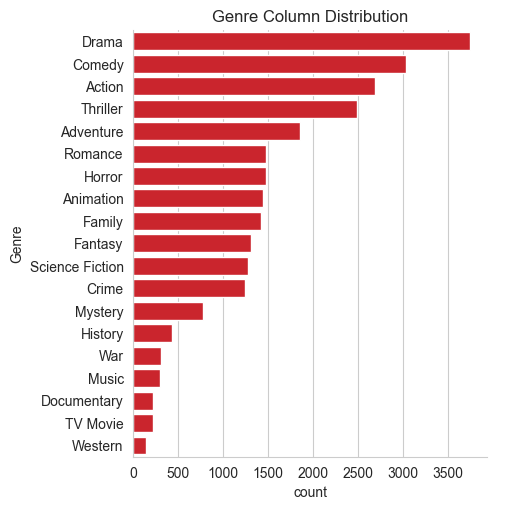

In [33]:
sns.catplot(y='Genre', data=df, kind='count', order=df['Genre'].value_counts().index, color="#e50914")
plt.title("Genre Column Distribution")
plt.show()

Which has highest votes in vote average column?

In [34]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


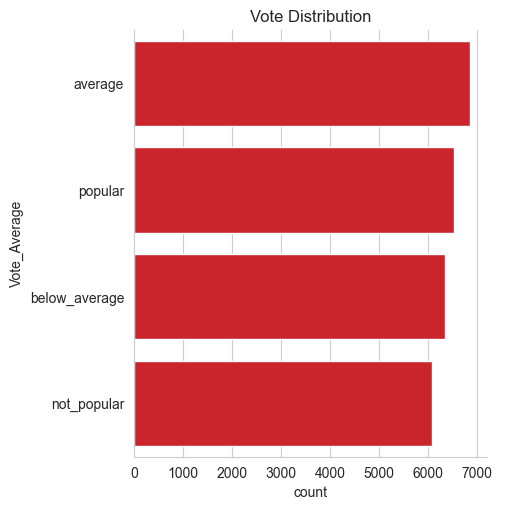

In [35]:
sns.catplot(y='Vote_Average', data=df, kind='count', order=df['Vote_Average'].value_counts().index, color='#e50914')
plt.title("Vote Distribution")
plt.show()

What movie got the highest popularity? whats its genre?

In [36]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [37]:
df[df['Popularity']==df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


What movie got the lowest popularity? whats its genre?

In [38]:
df[df['Popularity']==df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25786,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25787,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25788,2021,The United States vs. Billie Holiday,13.354,152,average,History
25789,1984,Threads,13.354,186,popular,War
25790,1984,Threads,13.354,186,popular,Drama
25791,1984,Threads,13.354,186,popular,Science Fiction


Which year has the most filmed movies?

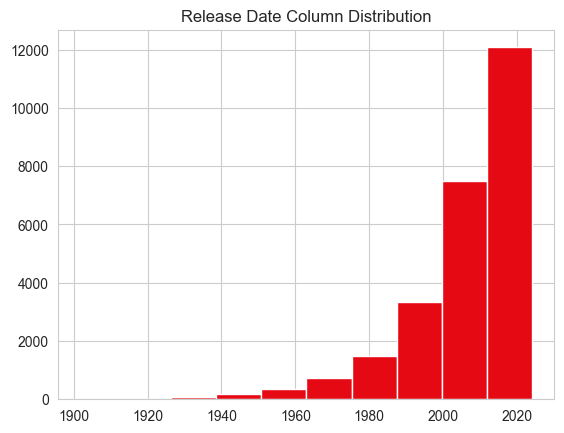

In [39]:
df['Release_Date'].hist(color='#e50914')
plt.title("Release Date Column Distribution")
plt.show()

• Drama is the most produced genre on Netflix, followed by Comedy and Action; Western and 
Documentary are the rarest. 

• Audience rating tiers (not_popular → popular) are nearly evenly split across the catalog — no single 
tier dominates. 

• Spider-Man: No Way Home (2021) is the standout outlier in popularity, scoring over 100× the 
median movie. 

• The least popular titles — The United States vs. Billie Holiday and Threads — come from very 
different genres and eras, showing popularity is not genre-bound. 

• Movie releases have grown dramatically since the 1980s, with the most recent years in the dataset 
(~2020-2024) accounting for the largest share of titles. 